In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('energy.csv')
print(df.head())
print(df.info())
print(df.describe())

# Check duplicate and missing values
print('any missing values?')
print(df.isna().sum())
print('any duplicate?')
print(df.duplicated().sum())

                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   

   RH_out  Windspeed  Visibility

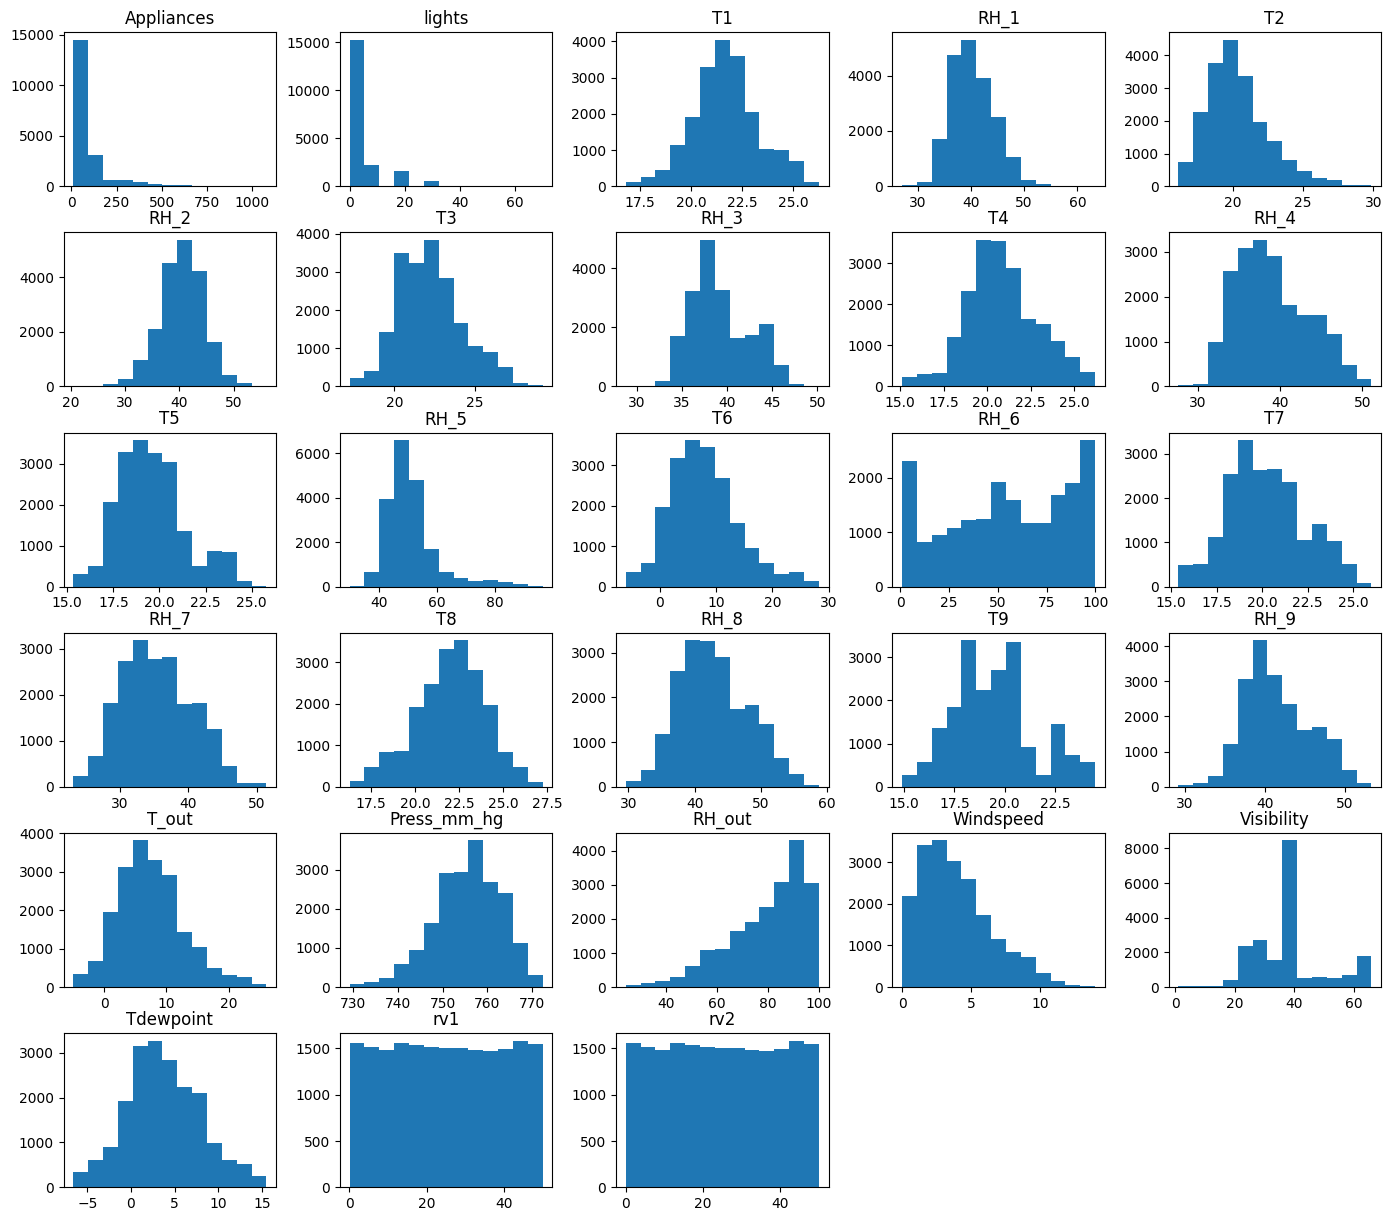

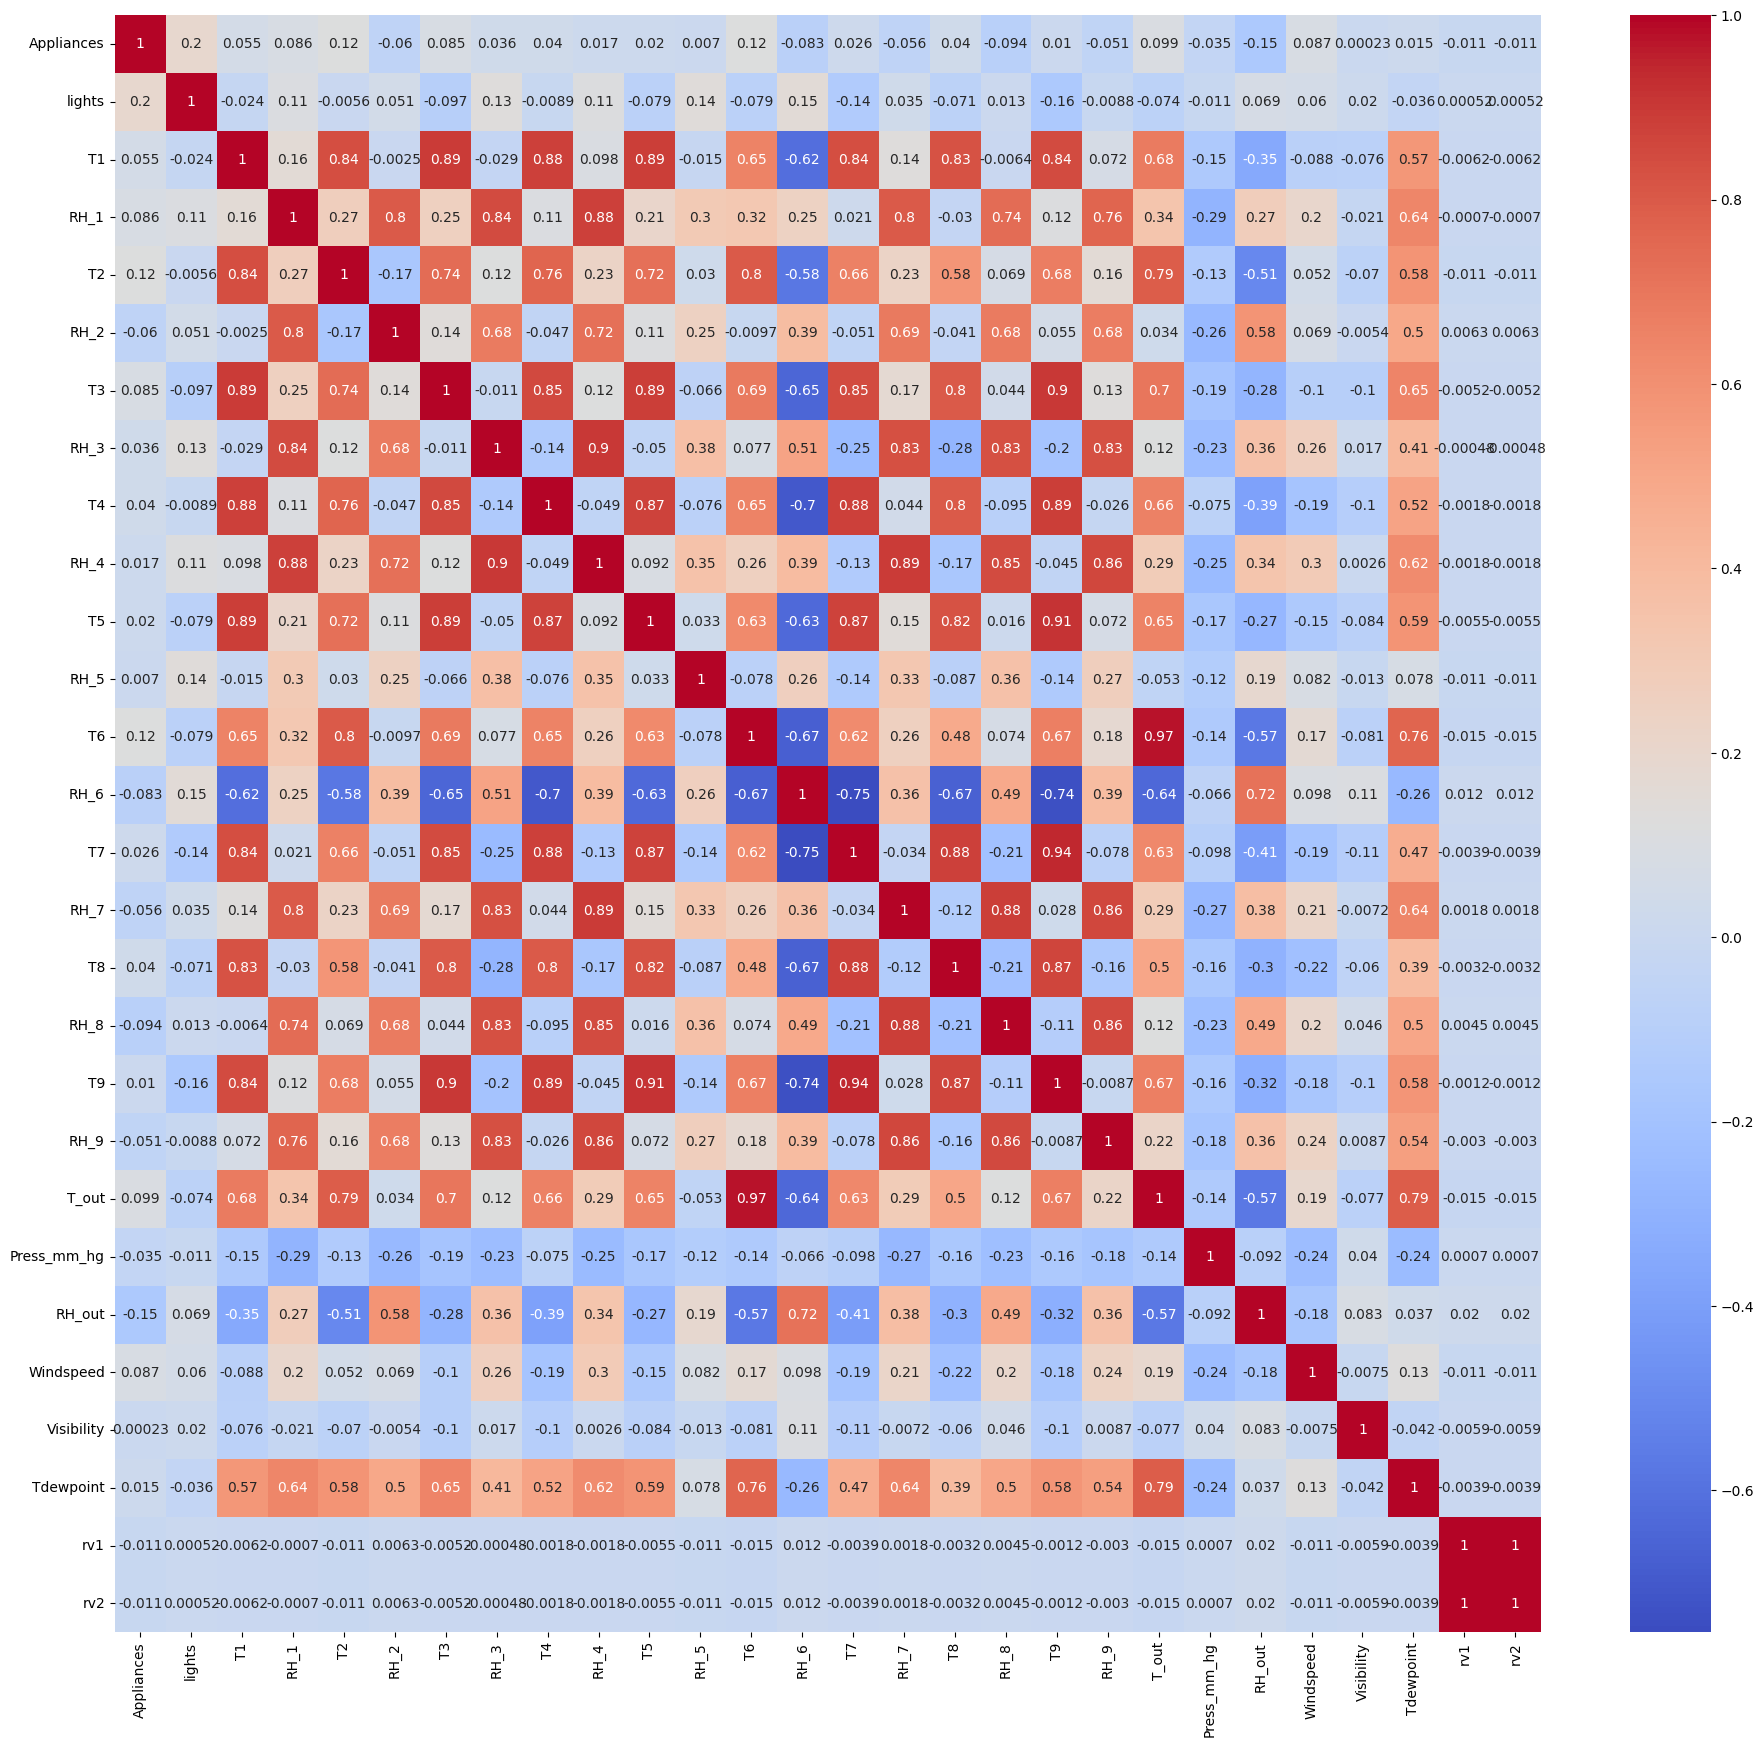

<Figure size 640x480 with 0 Axes>

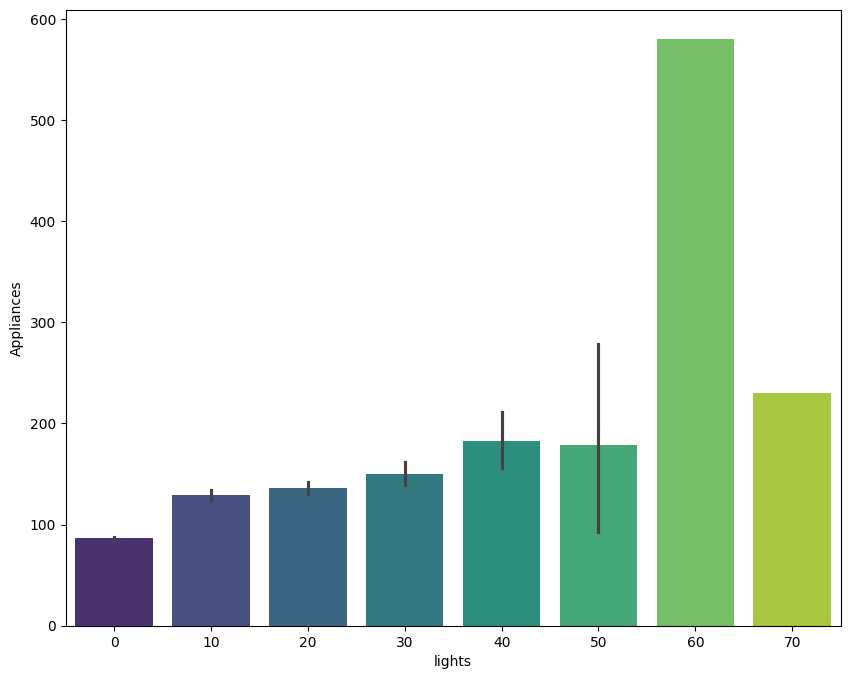

<Figure size 640x480 with 0 Axes>

In [17]:
# Visualize each feature's frequenty
df.hist(bins=13, grid=False, figsize=(17,15))
plt.show()

# Correlation with target (appliances)
plt.figure(figsize=(23,21))
sns.heatmap(data=df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

# Light vs appliances
plt.figure(figsize=(10,8))
sns.barplot(data=df, y='Appliances', x='lights', palette='viridis')
plt.figure()

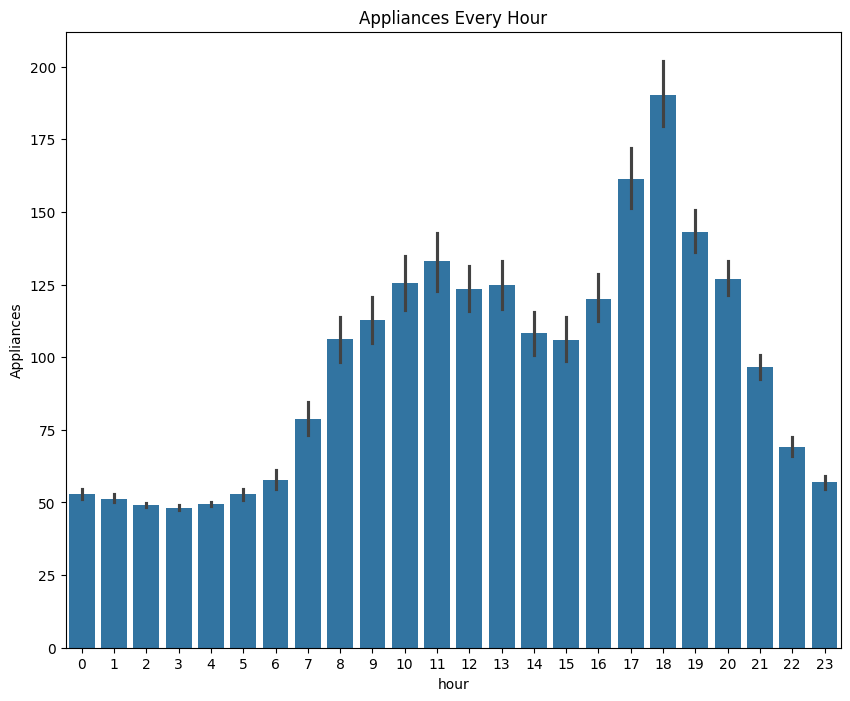

Evaluation Results
                              MAE  R2 Score
Linear Regression         51.4276    0.1999
Lasso                     51.5124    0.1770
Elastic Net               53.1884    0.1264
Random Forest Regression  30.3243    0.5835
Hist Gradient Boosting    36.7935    0.4650
Extra Tree Regressor      27.1326    0.6336


In [18]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop random noise cols & datetime parse
df['date'] = pd.to_datetime(df['date'])
df['hour']    = df['date'].dt.hour
df['weekday'] = df['date'].dt.weekday
df['month']   = df['date'].dt.month

# Cyclical encoding for time features (better than raw int)
df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)

# Visualize appliances every hour
plt.figure(figsize=(10,8))
sns.barplot(data=df, x='hour', y='Appliances', estimator=np.mean)
plt.title('Appliances Every Hour')
plt.show()

# Split data
x = df.drop(['Appliances','date','rv1','rv2'], axis=1)
y = df['Appliances']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


# Models
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Elastic Net': ElasticNet(),
    'Random Forest Regression': RandomForestRegressor(),
    'Hist Gradient Boosting': HistGradientBoostingRegressor(),
    'Extra Tree Regressor': ExtraTreesRegressor(),
}

results = {}
# Pipeline
for name, method in models.items():
    main_pipeline = Pipeline(steps=[
        ('Scaler', RobustScaler()),
        ('Models', method),
    ])
    main_pipeline.fit(x_train, y_train)
    predict = main_pipeline.predict(x_test)

    # Evaluate
    results[name] = {
        'MAE':      mean_absolute_error(y_test, predict),
        'R2 Score': r2_score(y_test, predict),
    }

# Make dataframe from results
print('Evaluation Results')
print(pd.DataFrame(results).T.round(4))

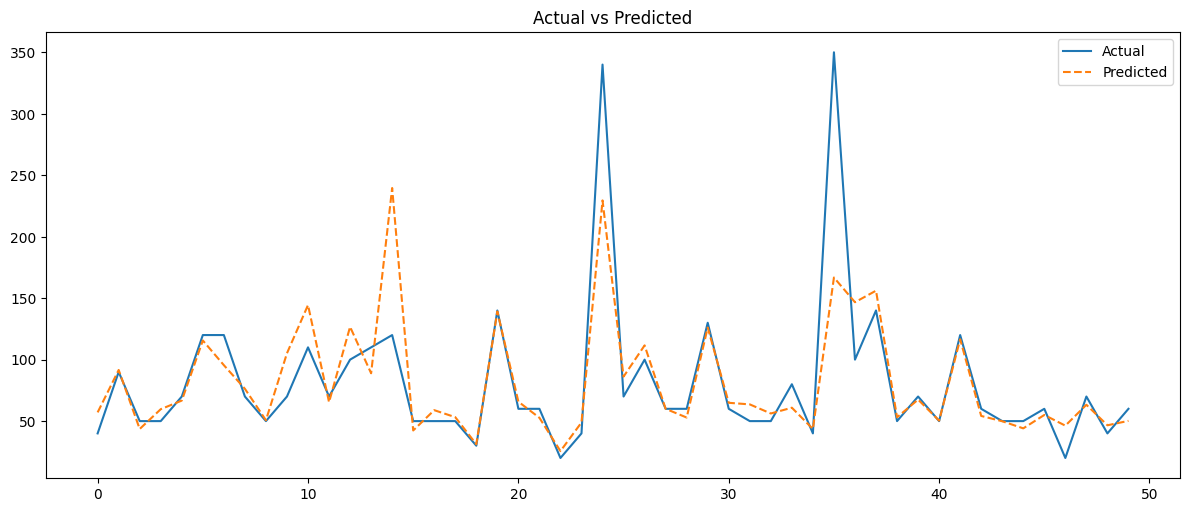

In [19]:
# Visualize predicted and actual
N = 50  
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_test.values[:N], label='Actual')
ax.plot(predict[:N],        label='Predicted', linestyle='--')
plt.tight_layout()
plt.title('Actual vs Predicted')
plt.legend()
plt.show()


In [20]:
# Best model from your pipeline loop
best_model = models['Extra Tree Regressor']

forecast_pipeline = Pipeline(steps=[
    ('Scaler', RobustScaler()),
    ('Models', best_model),
])
forecast_pipeline.fit(x_train, y_train)

# Recursive 24-hour predict
history  = y.tolist()
last_row = x.iloc[-1].copy()
last_time = pd.Timestamp.now().floor('h')

forecast_rows = []

for step in range(1, 25):
    next_time = last_time + pd.Timedelta(hours=step)

    # Update cyclical time features only
    last_row['hour_sin'] = np.sin(2 * np.pi * next_time.hour / 24)
    last_row['hour_cos'] = np.cos(2 * np.pi * next_time.hour / 24)

    # Predict
    x_step = pd.DataFrame([last_row])
    pred   = max(0, float(forecast_pipeline.predict(x_step)[0]))

    forecast_rows.append({'DateTime': next_time, 'Appliances Predicted': round(pred, 2)})

forecast_results = pd.DataFrame(forecast_rows)
print('\nNext 24-Hour Appliance Forecast')
print(forecast_results.to_string(index=False))



Next 24-Hour Appliance Forecast
           DateTime  Appliances Predicted
2026-06-23 17:00:00                 298.4
2026-06-23 18:00:00                 430.0
2026-06-23 19:00:00                 214.7
2026-06-23 20:00:00                 146.9
2026-06-23 21:00:00                 114.9
2026-06-23 22:00:00                  89.2
2026-06-23 23:00:00                  96.7
2026-06-24 00:00:00                  95.1
2026-06-24 01:00:00                  95.2
2026-06-24 02:00:00                  96.7
2026-06-24 03:00:00                 102.0
2026-06-24 04:00:00                 124.3
2026-06-24 05:00:00                 120.8
2026-06-24 06:00:00                 177.7
2026-06-24 07:00:00                 188.0
2026-06-24 08:00:00                 232.4
2026-06-24 09:00:00                 237.2
2026-06-24 10:00:00                 232.5
2026-06-24 11:00:00                 240.9
2026-06-24 12:00:00                 235.4
2026-06-24 13:00:00                 235.4
2026-06-24 14:00:00                 224.5
2